In [1]:
import MDAnalysis as mda
from matplotlib import pyplot as plt
from MDAnalysis.analysis import contacts
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
# suppress some MDAnalysis warnings about PSF files
warnings.filterwarnings('ignore')
from MDAnalysis.analysis import distances

d:\anaconda\envs\mdanalysis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
xtc_file = ["E:/a40/a40/200_700.xtc","E:/a40/a40p8/200_750.xtc","E:/a40/a40p26/200_700.xtc"]
gro_file = ["E:/a40/a40/md_p.gro","E:/a40/a40p8/md_p.gro","E:/a40/a40p26/md_p.gro"]
png = ["E:/a40/cont_a40.png","E:/a40/cont_a40p8.png" ,"E:/a40/cont_a40p26.png" ]
txt = ["E:/a40/cont_a40.txt","E:/a40/cont_a40p8.txt" ,"E:/a40/cont_a40p26.txt"]

In [3]:
def contact_prob(u, radius=8,start=20000):
    """
    计算轨迹中每一帧的接触矩阵，并计算接触矩阵的平均值。

    参数：
    - u: MDAnalysis的Universe对象，包含轨迹和结构数据。
    - radius: 接触的距离阈值（单位为Å），默认为8.0 Å。

    返回：
    - avg_cont: 所有轨迹帧的接触矩阵的平均值。
    """
    timeseries = []
    ca_atoms = u.select_atoms("name CA")  # 选择CA原子

    # 遍历轨迹中的每一帧
    for ts in u.trajectory[start:]:
        # 计算每对CA原子之间的距离矩阵
        dist = distances.distance_array(ca_atoms.positions, ca_atoms.positions, box=u.dimensions)
        
        # 计算接触矩阵（假设接触阈值为radius）
        contact_matrix = (dist <= radius).astype(int)
        
        # 将当前帧的接触矩阵和帧编号添加到timeseries列表
        timeseries.append([ts.frame, contact_matrix])

    # 计算接触矩阵的平均值
    avg_cont = np.mean([x[1] for x in timeseries], axis=0)

    return avg_cont

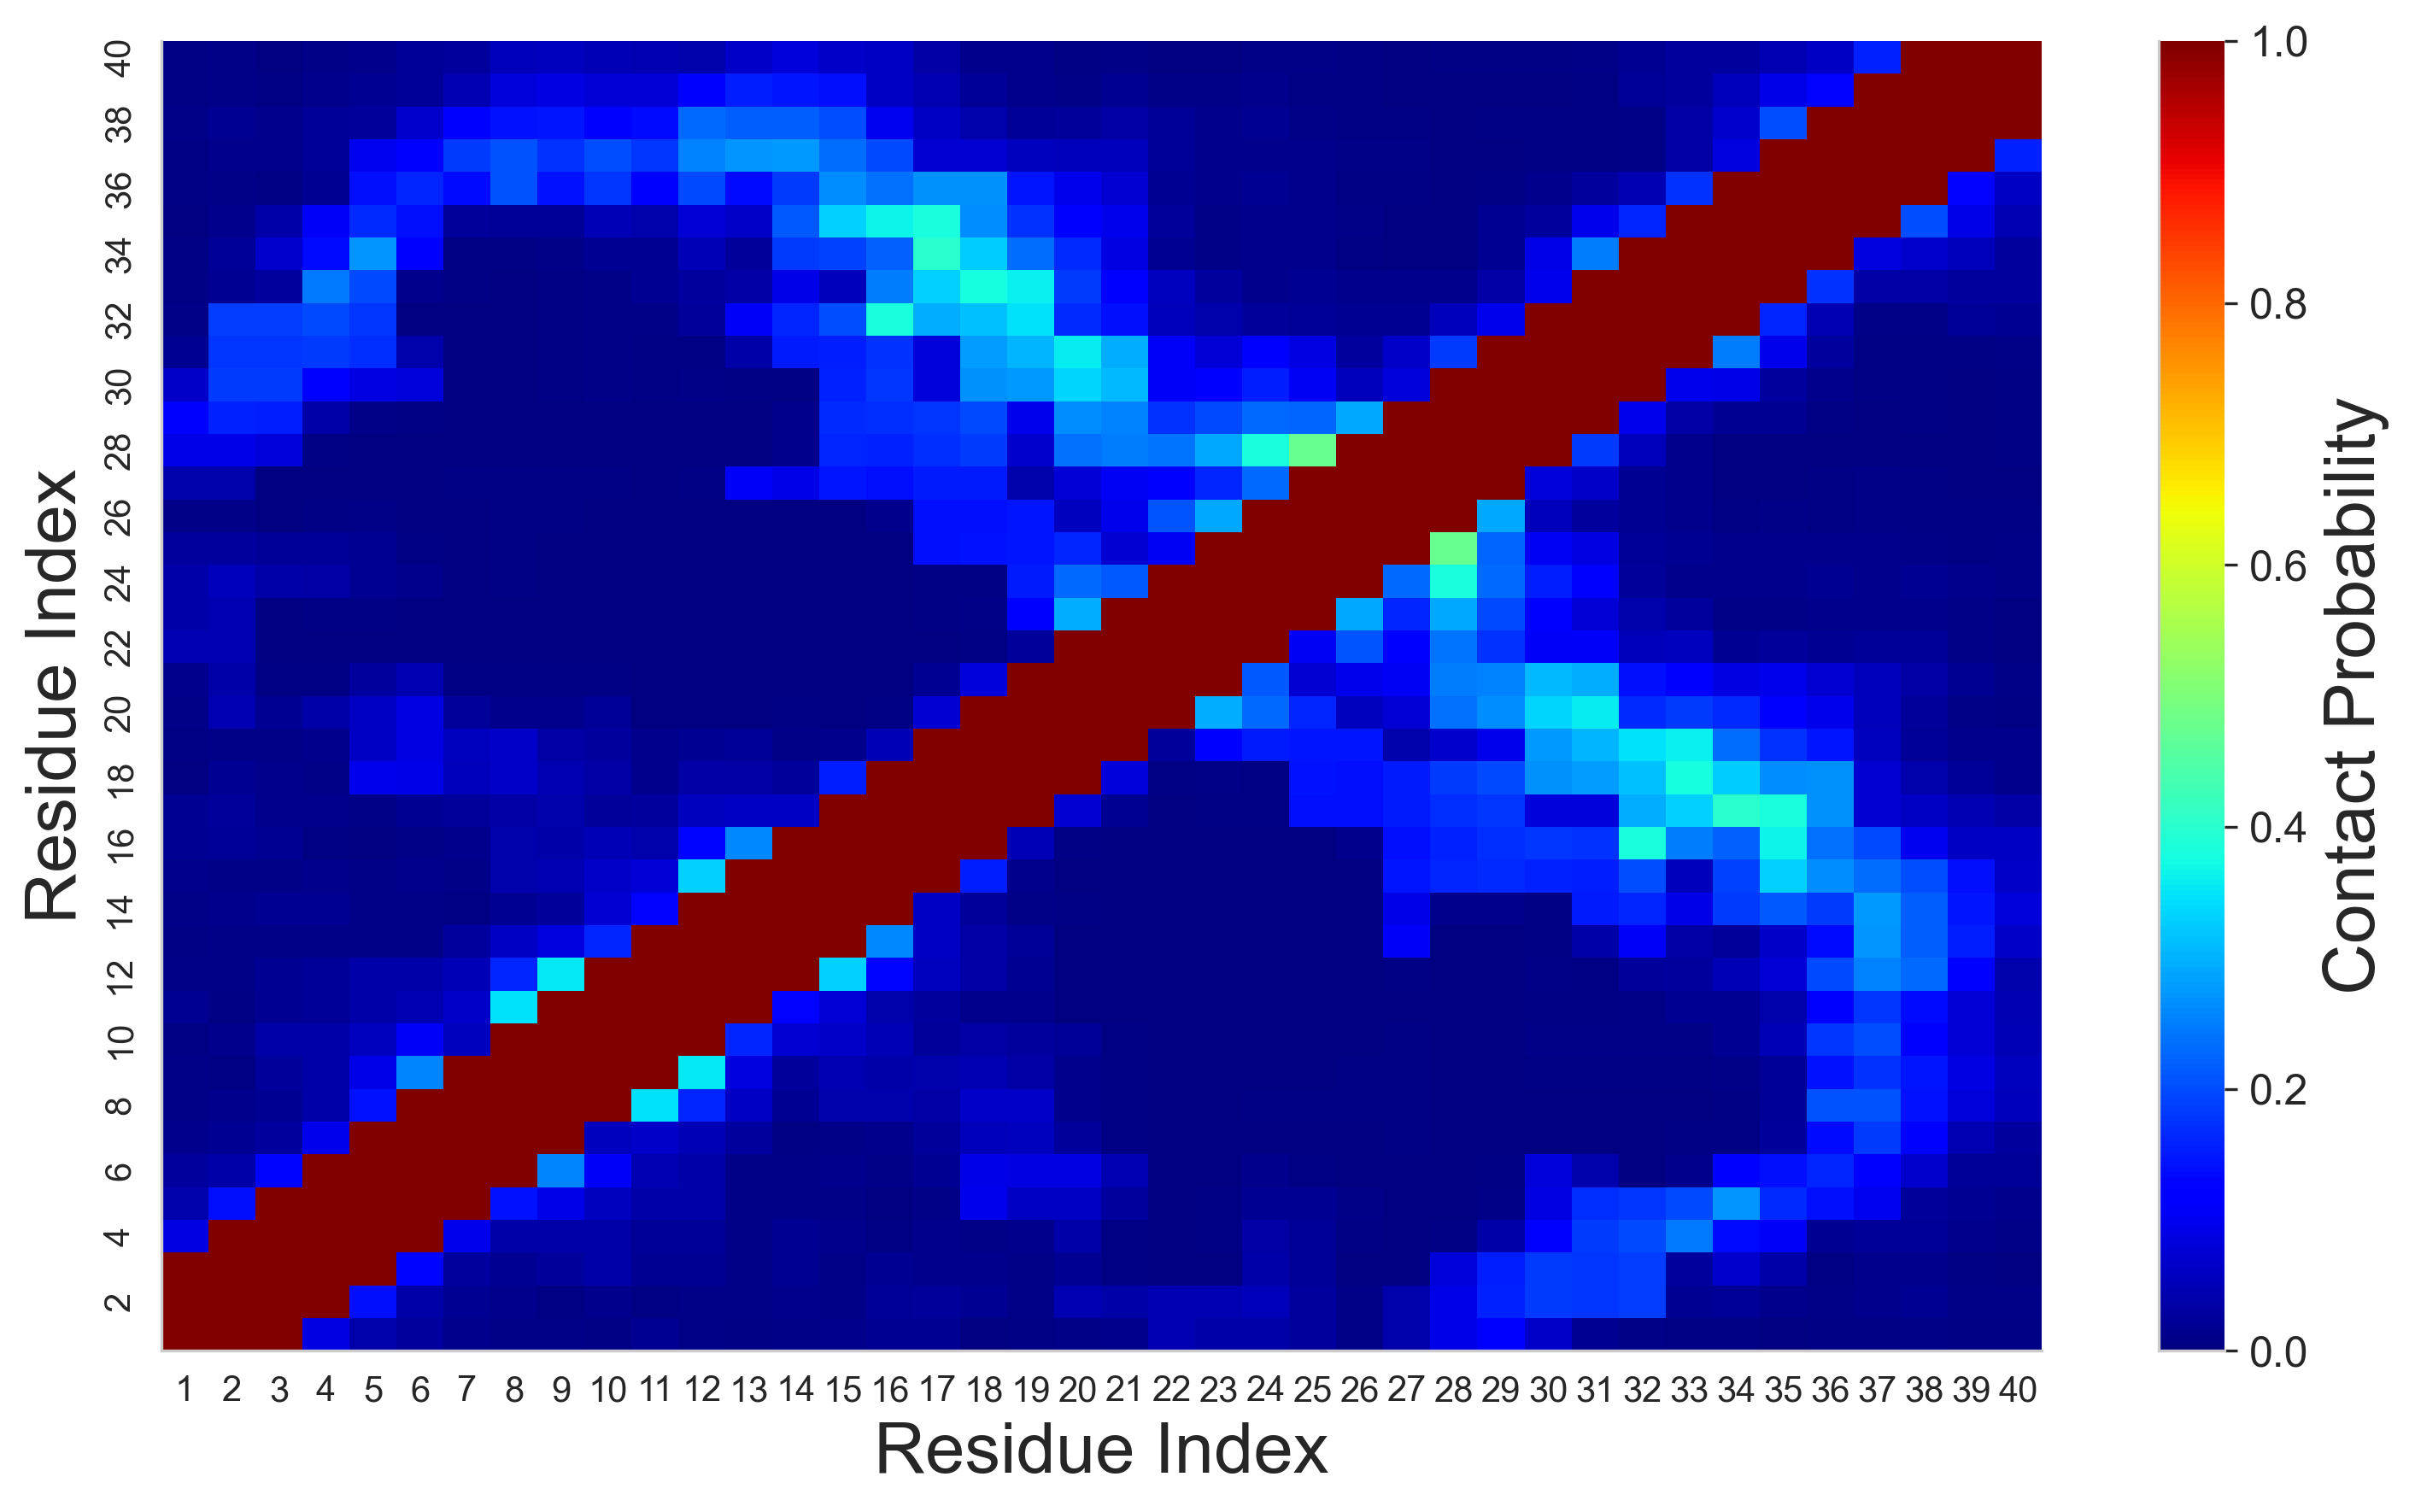

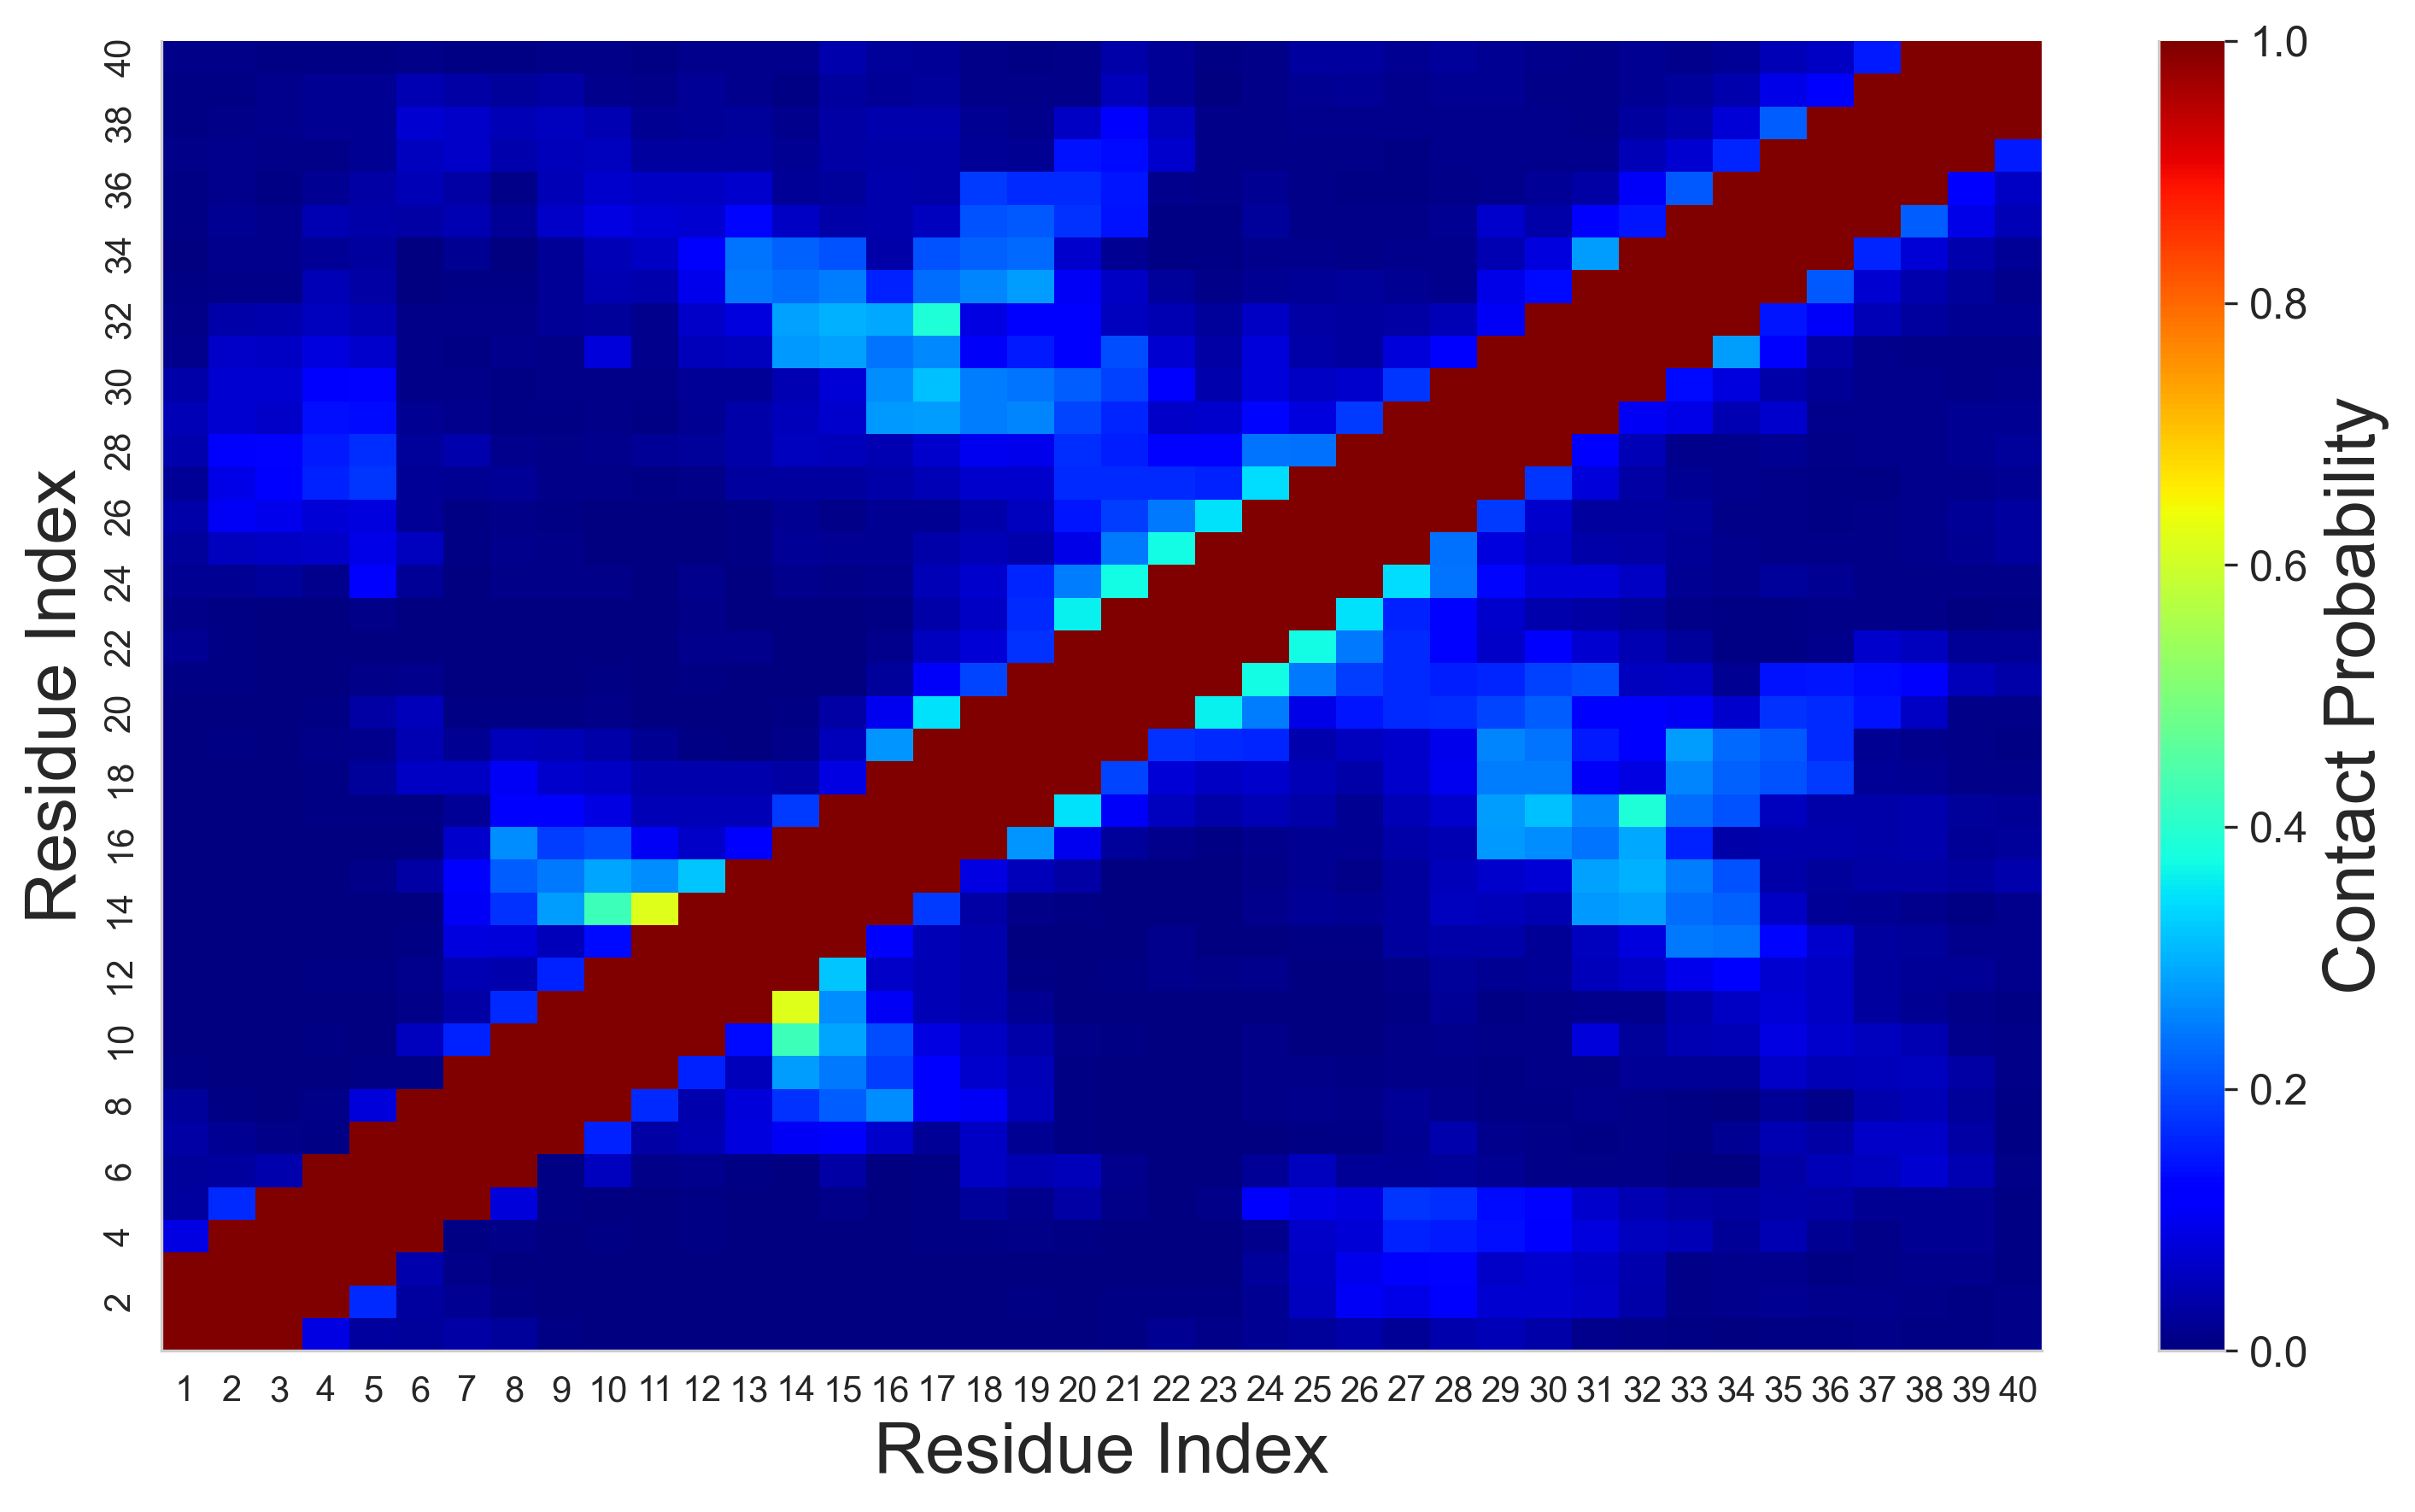

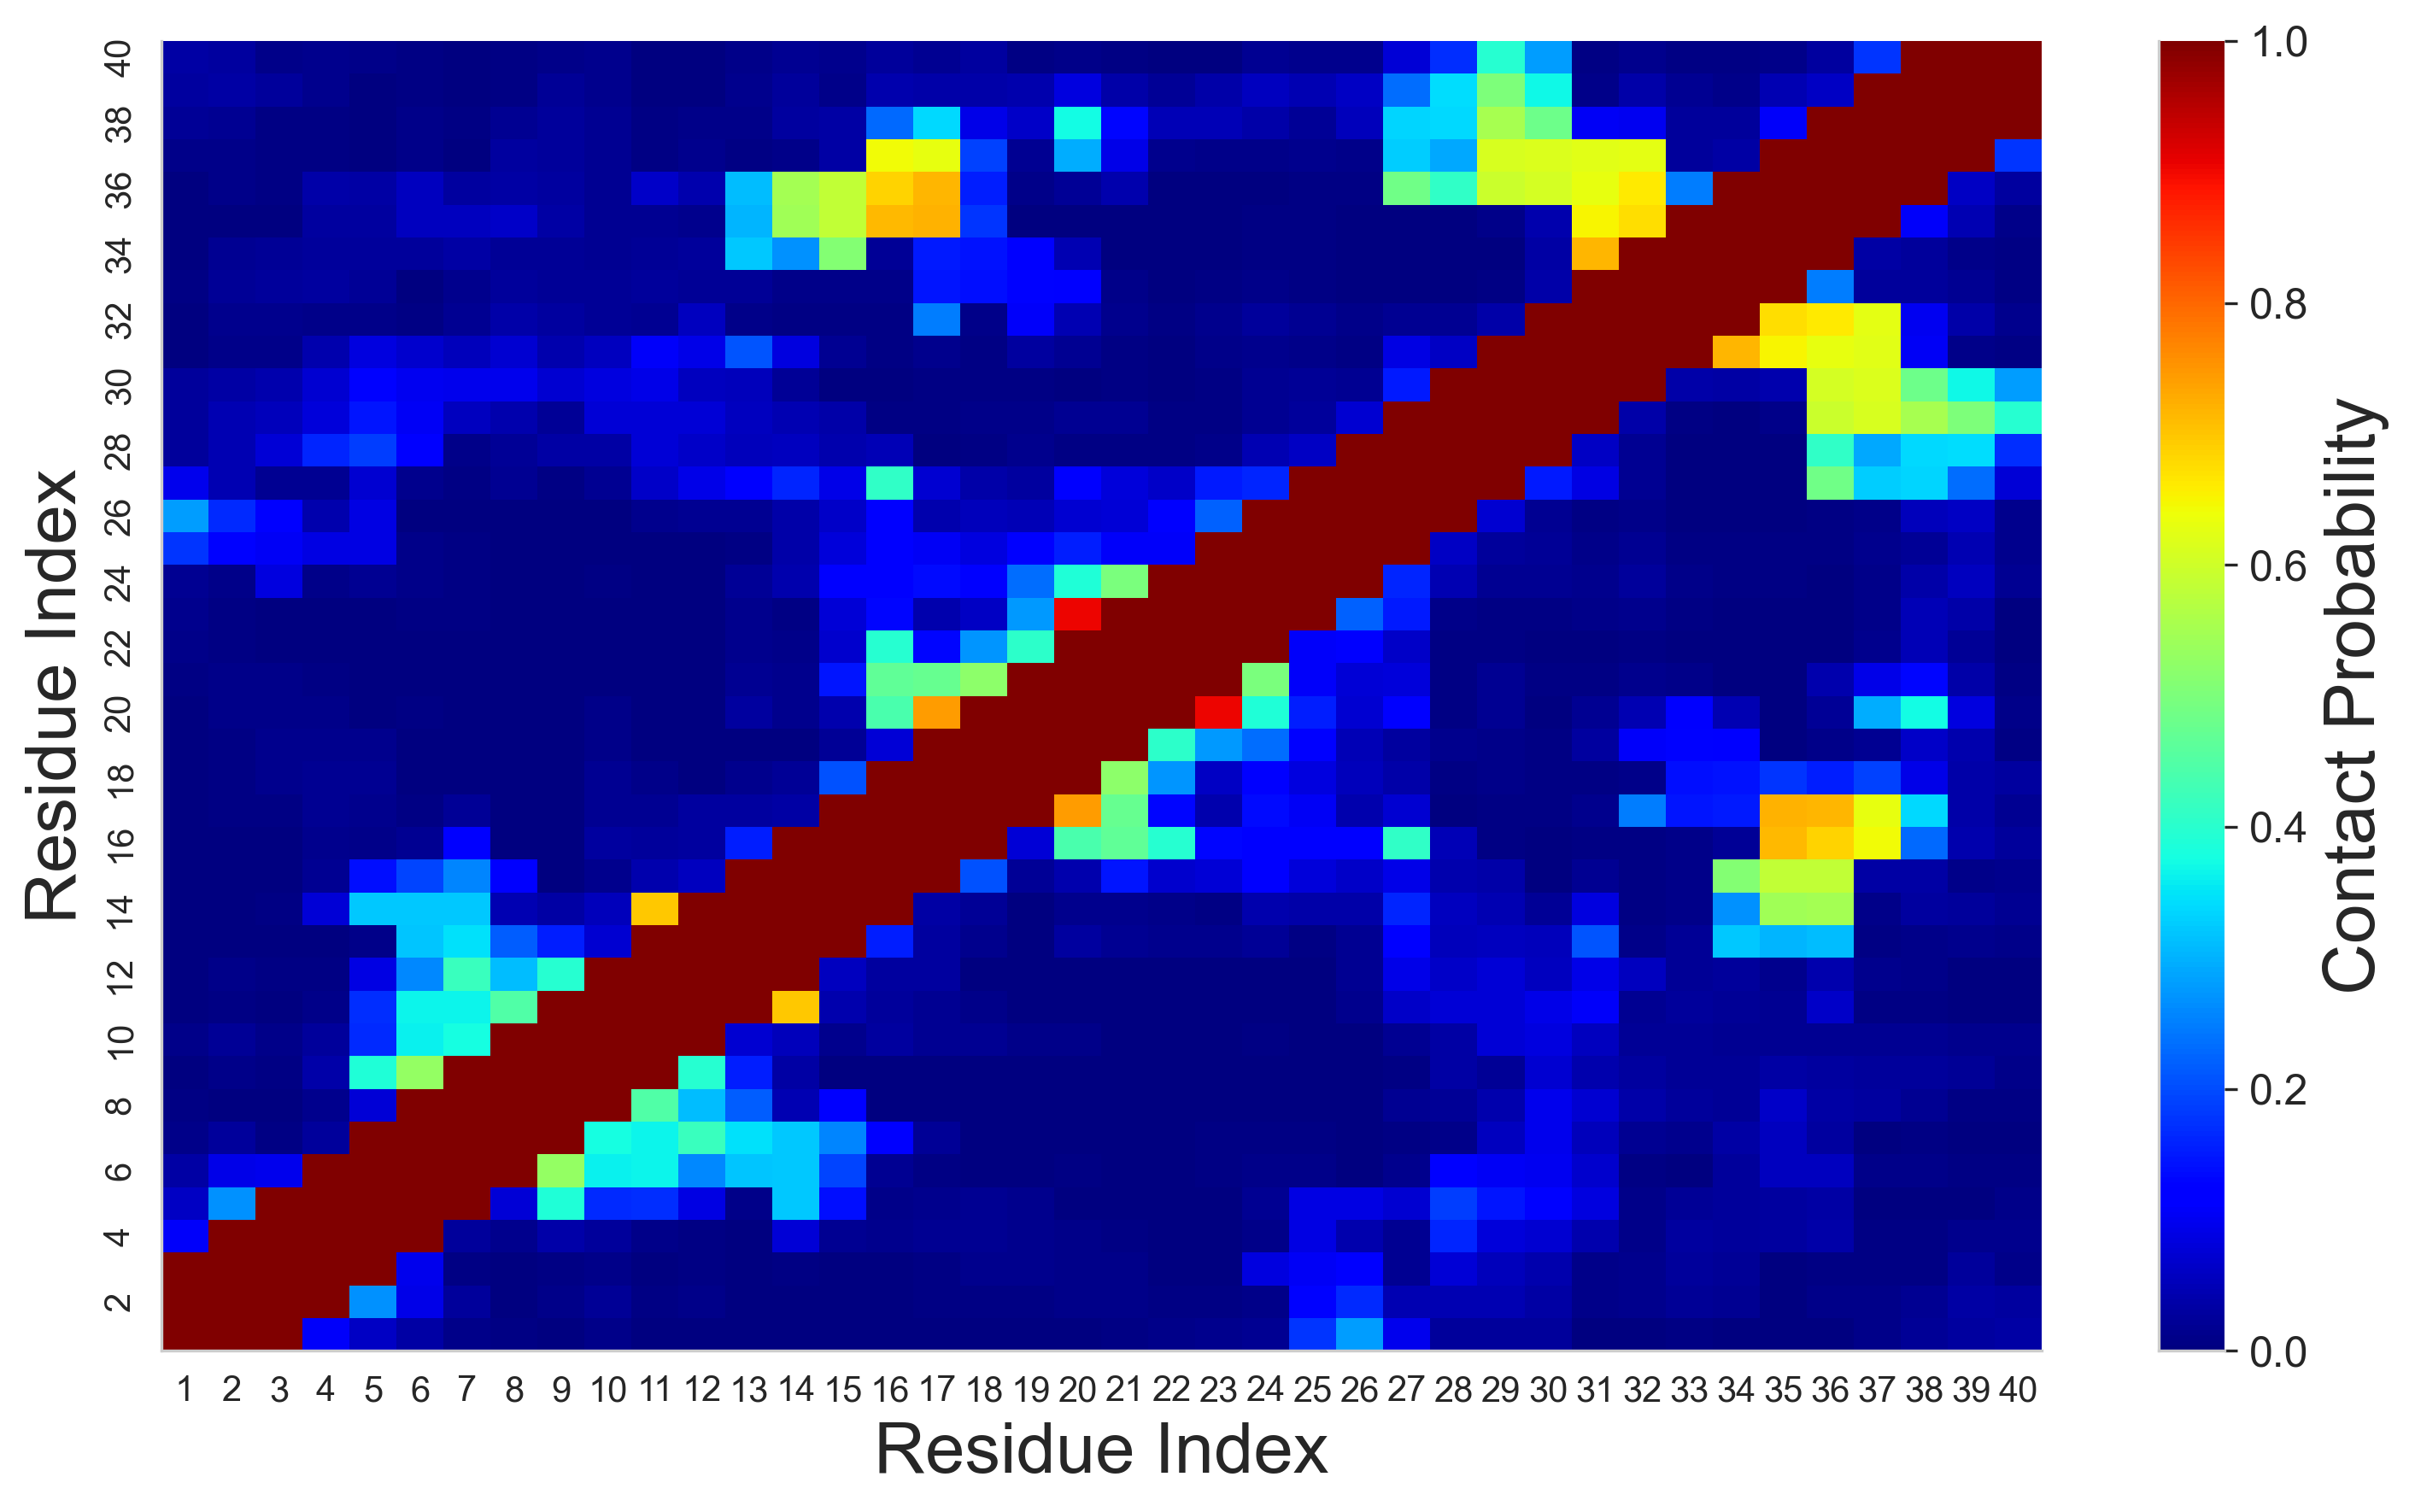

In [ ]:
for i, j, a, t in zip(xtc_file, gro_file,png, txt):
    u = mda.Universe(j,i)
    tol = contact_prob(u,8,start=0)
    df = pd.DataFrame(tol)
    df.columns = range(1,41)
    df.index = range(1,41)
    np.savetxt(t,df)
    df = df.loc[::-1]
    plt.figure(figsize=(10, 7.5), dpi=600)
    sns.set_style("whitegrid")
    ax = sns.heatmap(df,cmap='jet',cbar_kws={'label': 'Contact Probability'})
    ax.set_xlabel('Residue Index', fontsize=30)
    ax.set_ylabel('Residue Index', fontsize=30)
    # Remove the top and right borders for a cleaner look
    sns.despine()
    # Customize colorbar label font size
    cbar = ax.collections[0].colorbar  # Get the colorbar object
    cbar.set_label('Contact Probability', fontsize=20)  # Set label with desired fontsize
    cbar.ax.tick_params(labelsize=12)  # Optionally set the font size of the ticks
    plt.tight_layout()
    plt.savefig(a)

In [13]:
nac = mda.Universe("E:/cgnac_sirah/monomer/nac/md_p.gro","E:/cgnac_sirah/monomer/nac/md_p.xtc")
pnac = mda.Universe("E:/cgnac_sirah/monomer/pnac/md_p.gro","E:/cgnac_sirah/monomer/pnac/md_p.xtc")

C:\Users\11065\AppData\Local\Temp\ipykernel_25608\2526995876.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(t, delim_whitespace=True, header=None)  # 根据TXT文件的格式选择合适的分隔符


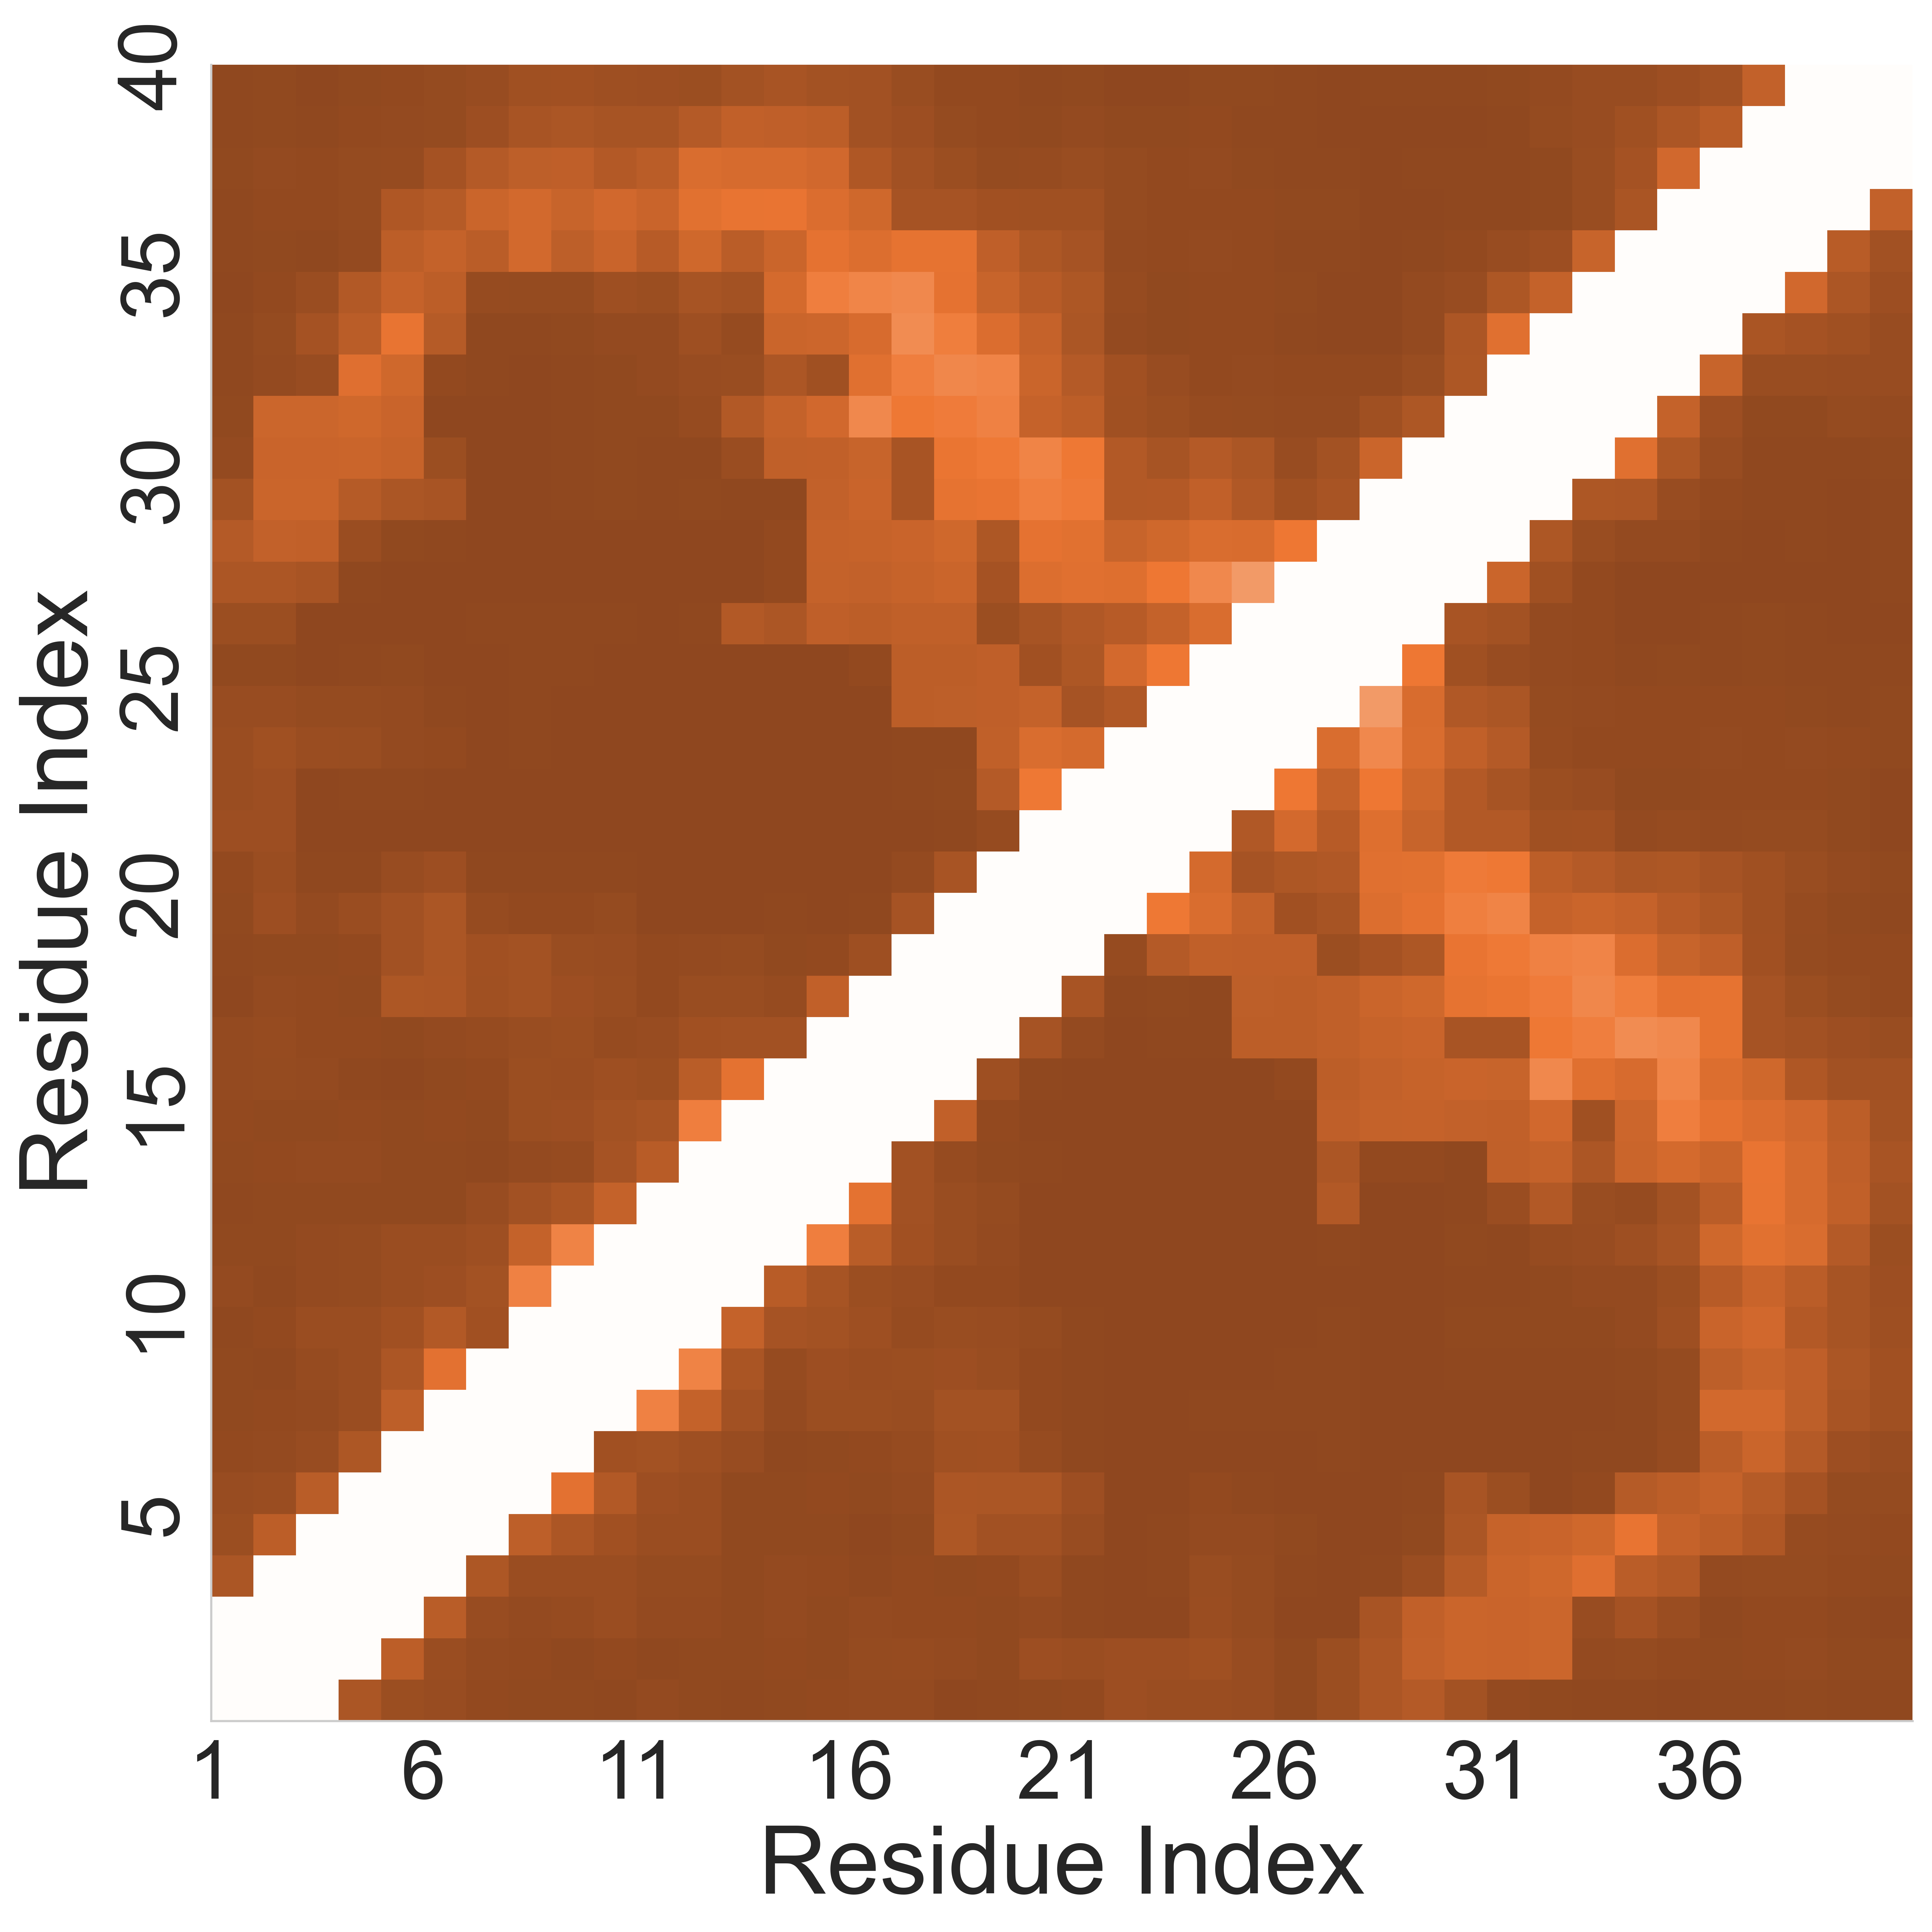

C:\Users\11065\AppData\Local\Temp\ipykernel_25608\2526995876.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(t, delim_whitespace=True, header=None)  # 根据TXT文件的格式选择合适的分隔符


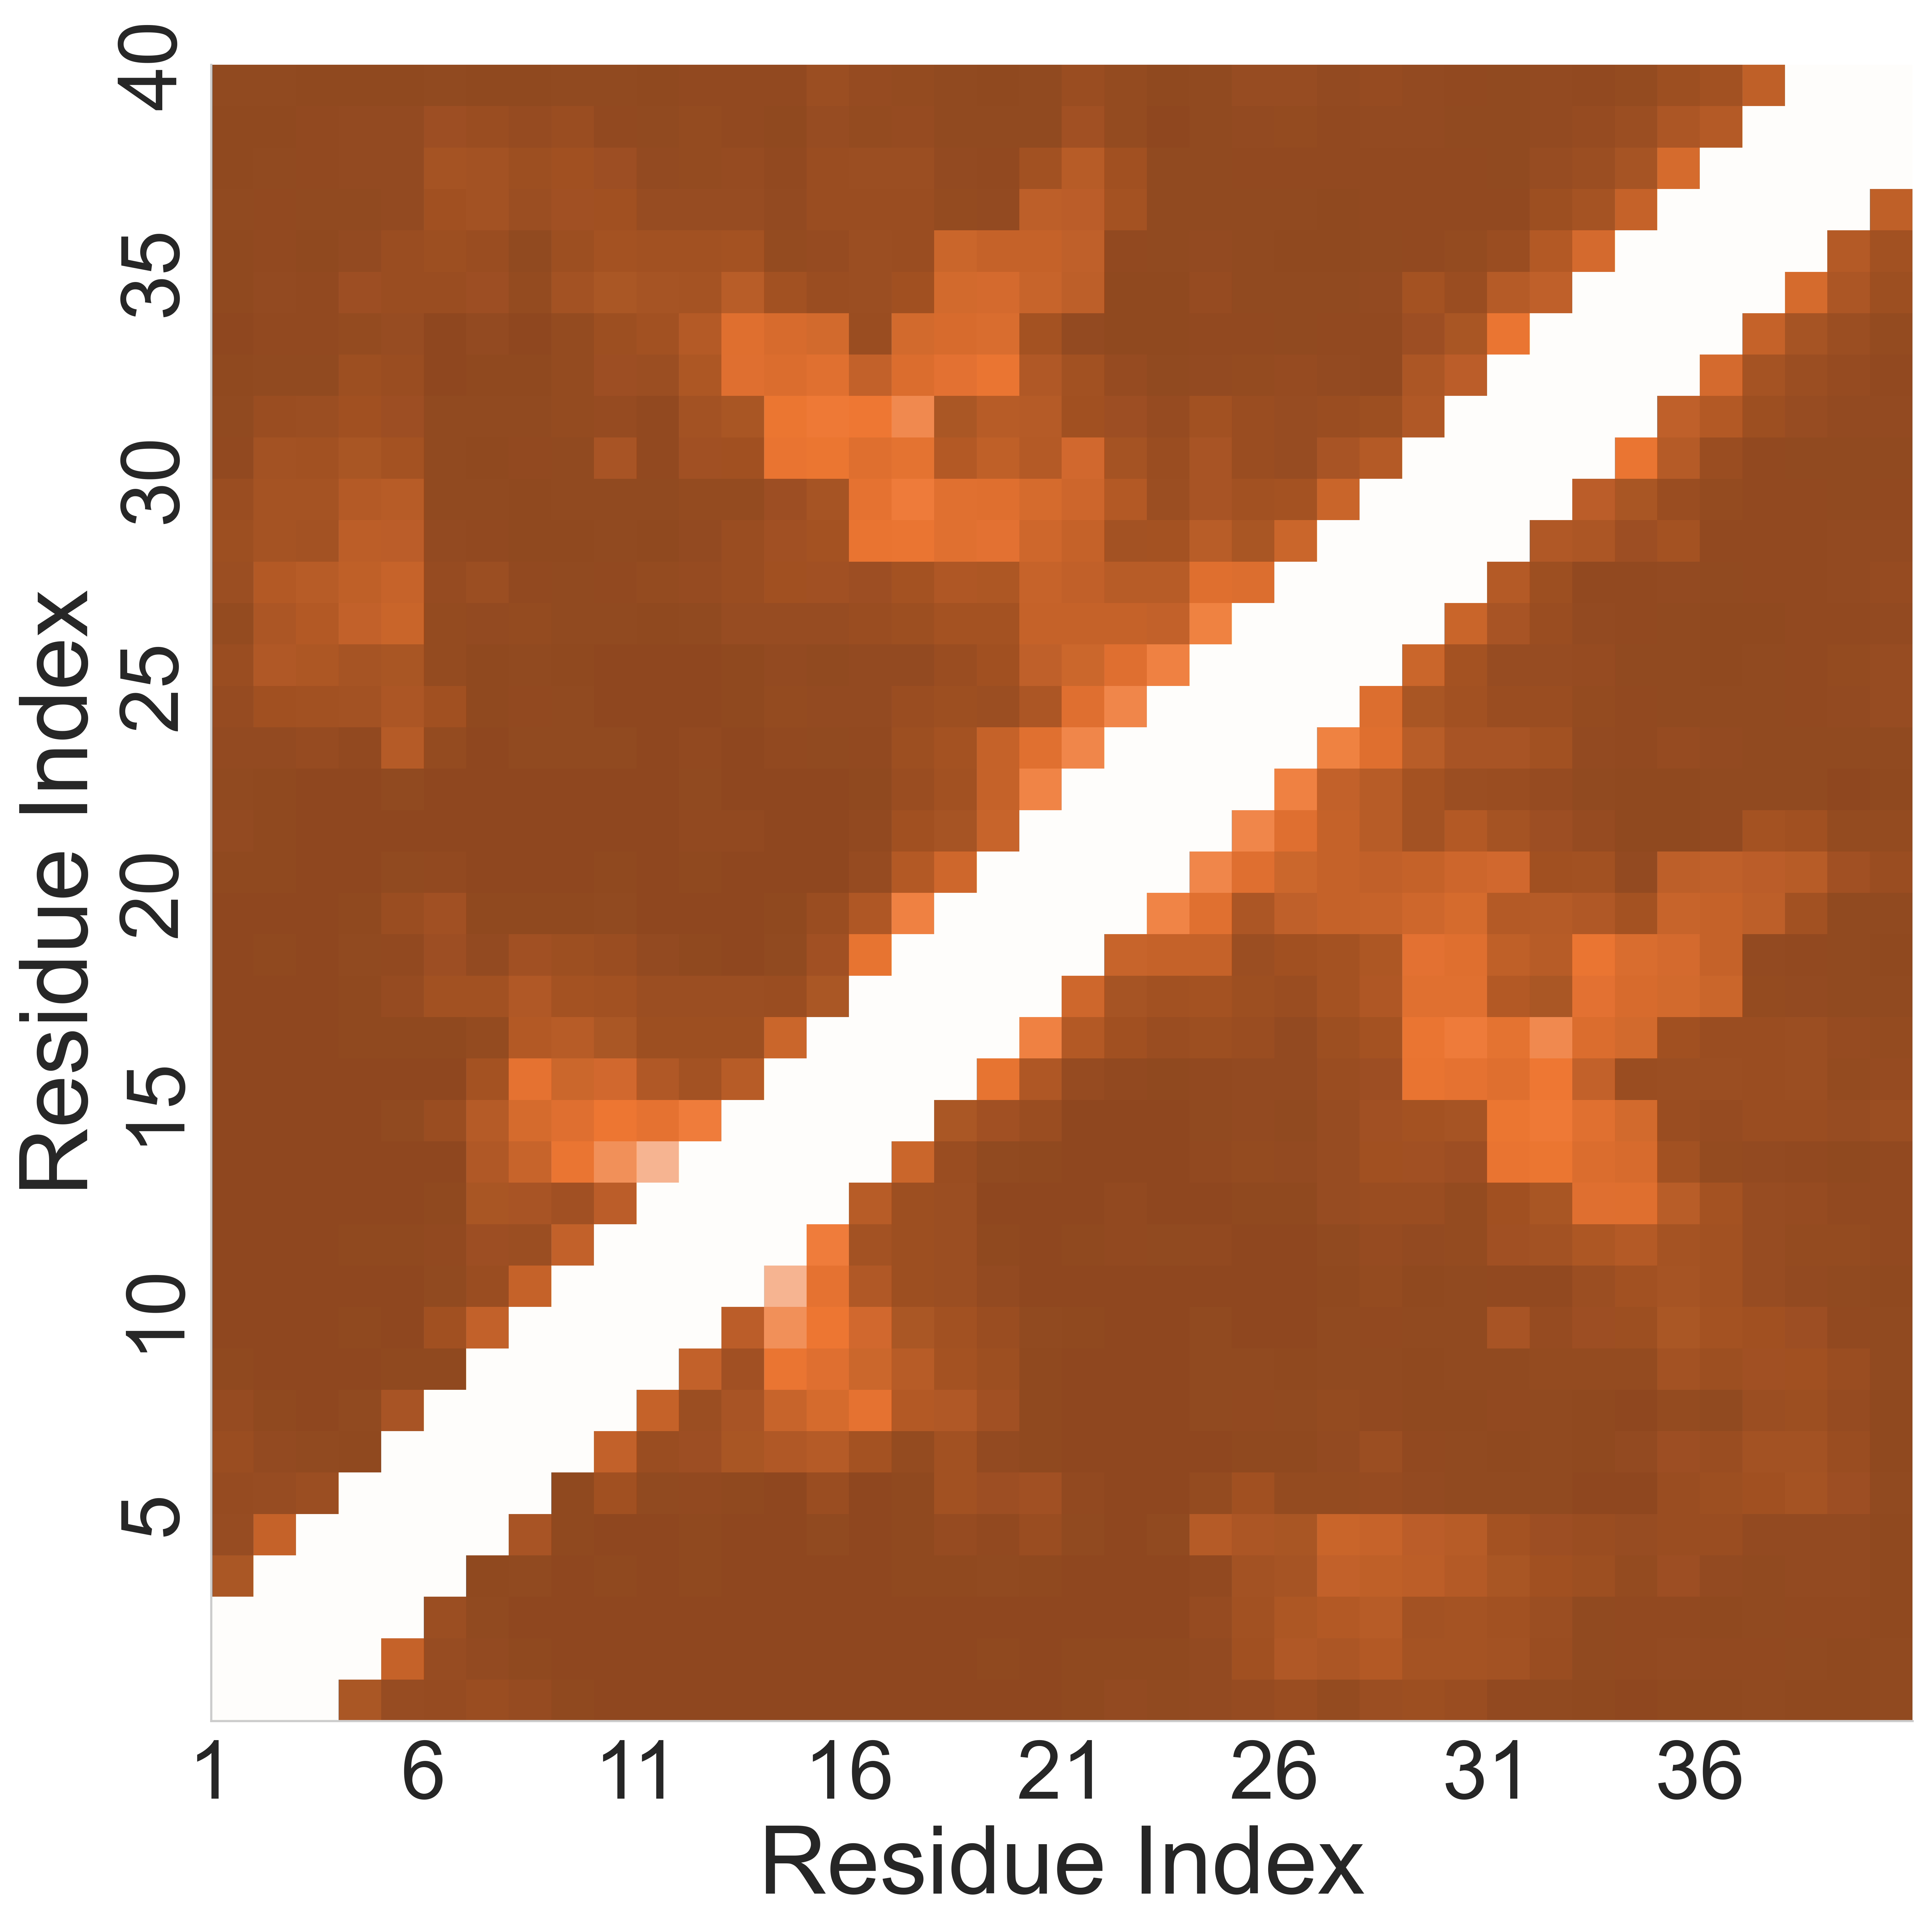

C:\Users\11065\AppData\Local\Temp\ipykernel_25608\2526995876.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(t, delim_whitespace=True, header=None)  # 根据TXT文件的格式选择合适的分隔符


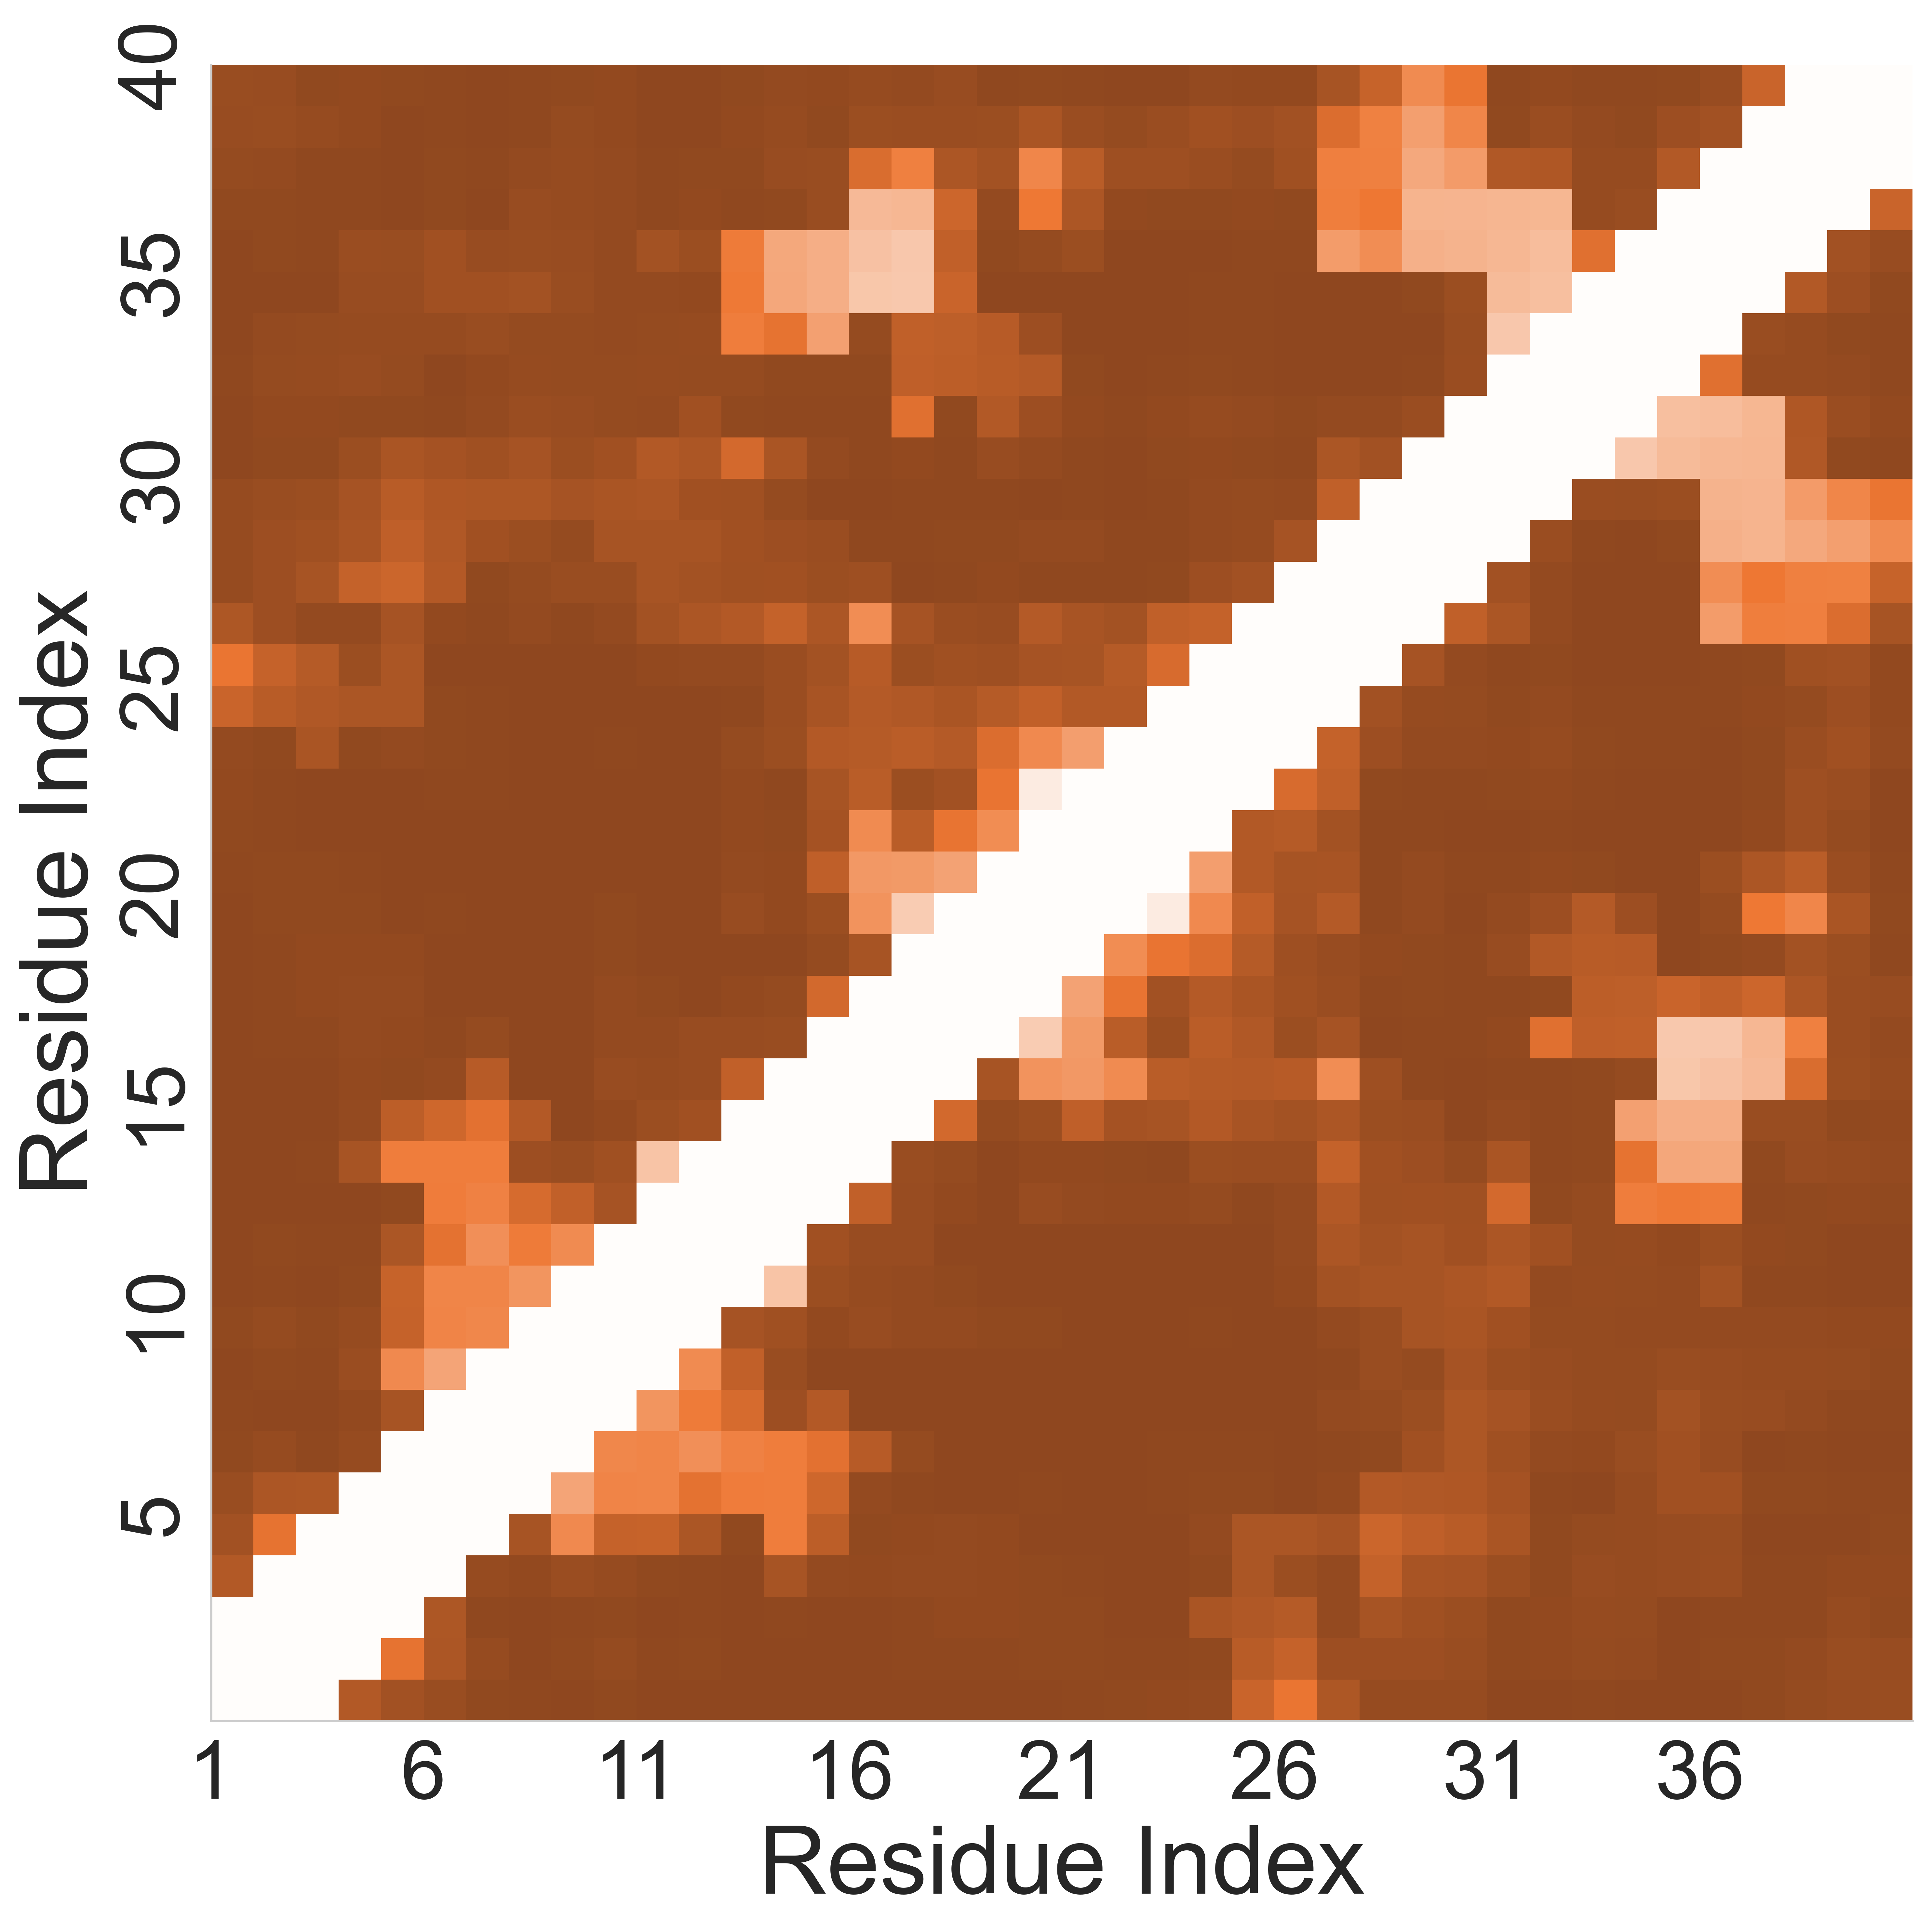

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
png = ["E:/a40/cont_a40.png","E:/a40/cont_a40p8.png" ,"E:/a40/cont_a40p26.png" ]
# 替换为您的 TXT 文件路径
txt_files = ["E:/a40/cont_a40.txt", "E:/a40/cont_a40p8.txt", "E:/a40/cont_a40p26.txt"]
oranges = [(0, 0, 0), '#EE7733', (1, 1, 1)] 
oranges = mpl.colors.LinearSegmentedColormap.from_list('oranges', oranges, N=1000)
oranges = mpl.colors.LinearSegmentedColormap.from_list(
          'trunc(oranges.name,.3,.99)', oranges(np.linspace(.3, .99, 1000)))
for t,png in zip(txt_files,png):
    # 从 TXT 文件加载数据
    df = pd.read_csv(t, delim_whitespace=True, header=None)  # 根据TXT文件的格式选择合适的分隔符
    df.columns = range(1, 41)  # 如果数据列数是 40，设置相应的列名
    df.index = range(1, 41)  # 设置行索引

    # 反转数据框，如果需要
    df = df.loc[::-1]

    # 绘制热图
    plt.figure(figsize=(10, 10), dpi=600)
    sns.set_style("whitegrid")

    # 创建热图
    ax = sns.heatmap(df, cmap=oranges, cbar_kws={'label': 'Contact Probability'},cbar=False)
    ax.set_xlabel('Residue Index', fontsize=35)
    ax.set_ylabel('Residue Index', fontsize=35)
    x_tick_positions = np.arange(0, df.shape[1], 5)  # 每5个位置
    x_tick_labels = np.arange(1, df.shape[1] + 1, 5)  # 生成（1, 5, 10, ... , 40）
    ax.set_xticks(x_tick_positions)  # 设置 X 轴刻度位置
    ax.set_xticklabels(x_tick_labels, fontsize=30)  # 设置 X 轴刻度标签

    # 设置 Y 轴刻度
    y_tick_positions = np.arange(0, df.shape[0], 5)  # Y 轴每5个位置
    y_tick_labels = np.arange(1, df.shape[0] + 1)[::-1][y_tick_positions]  # 反转标签（从40到1）
    
    ax.set_yticks(y_tick_positions)  # 设置 Y 轴刻度位置
    ax.set_yticklabels(y_tick_labels, fontsize=30)  # 设置 Y 轴刻度标签
    sns.despine()

    # 定制颜色条的标签字体大小
    cbar = ax.collections[0].colorbar  # 获取颜色条对象
    #cbar.set_label('Contact Probability', fontsize=35)  # 设置标签
    #cbar.ax.tick_params(labelsize=30)  # 设置刻度字体大小

    plt.tight_layout()
    
    # 保存热图
    plt.savefig(png)
    plt.show()


C:\Users\11065\AppData\Local\Temp\ipykernel_25608\1128554340.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(txt_file, delim_whitespace=True, header=None)  # 根据TXT文件的格式选择合适的分隔符


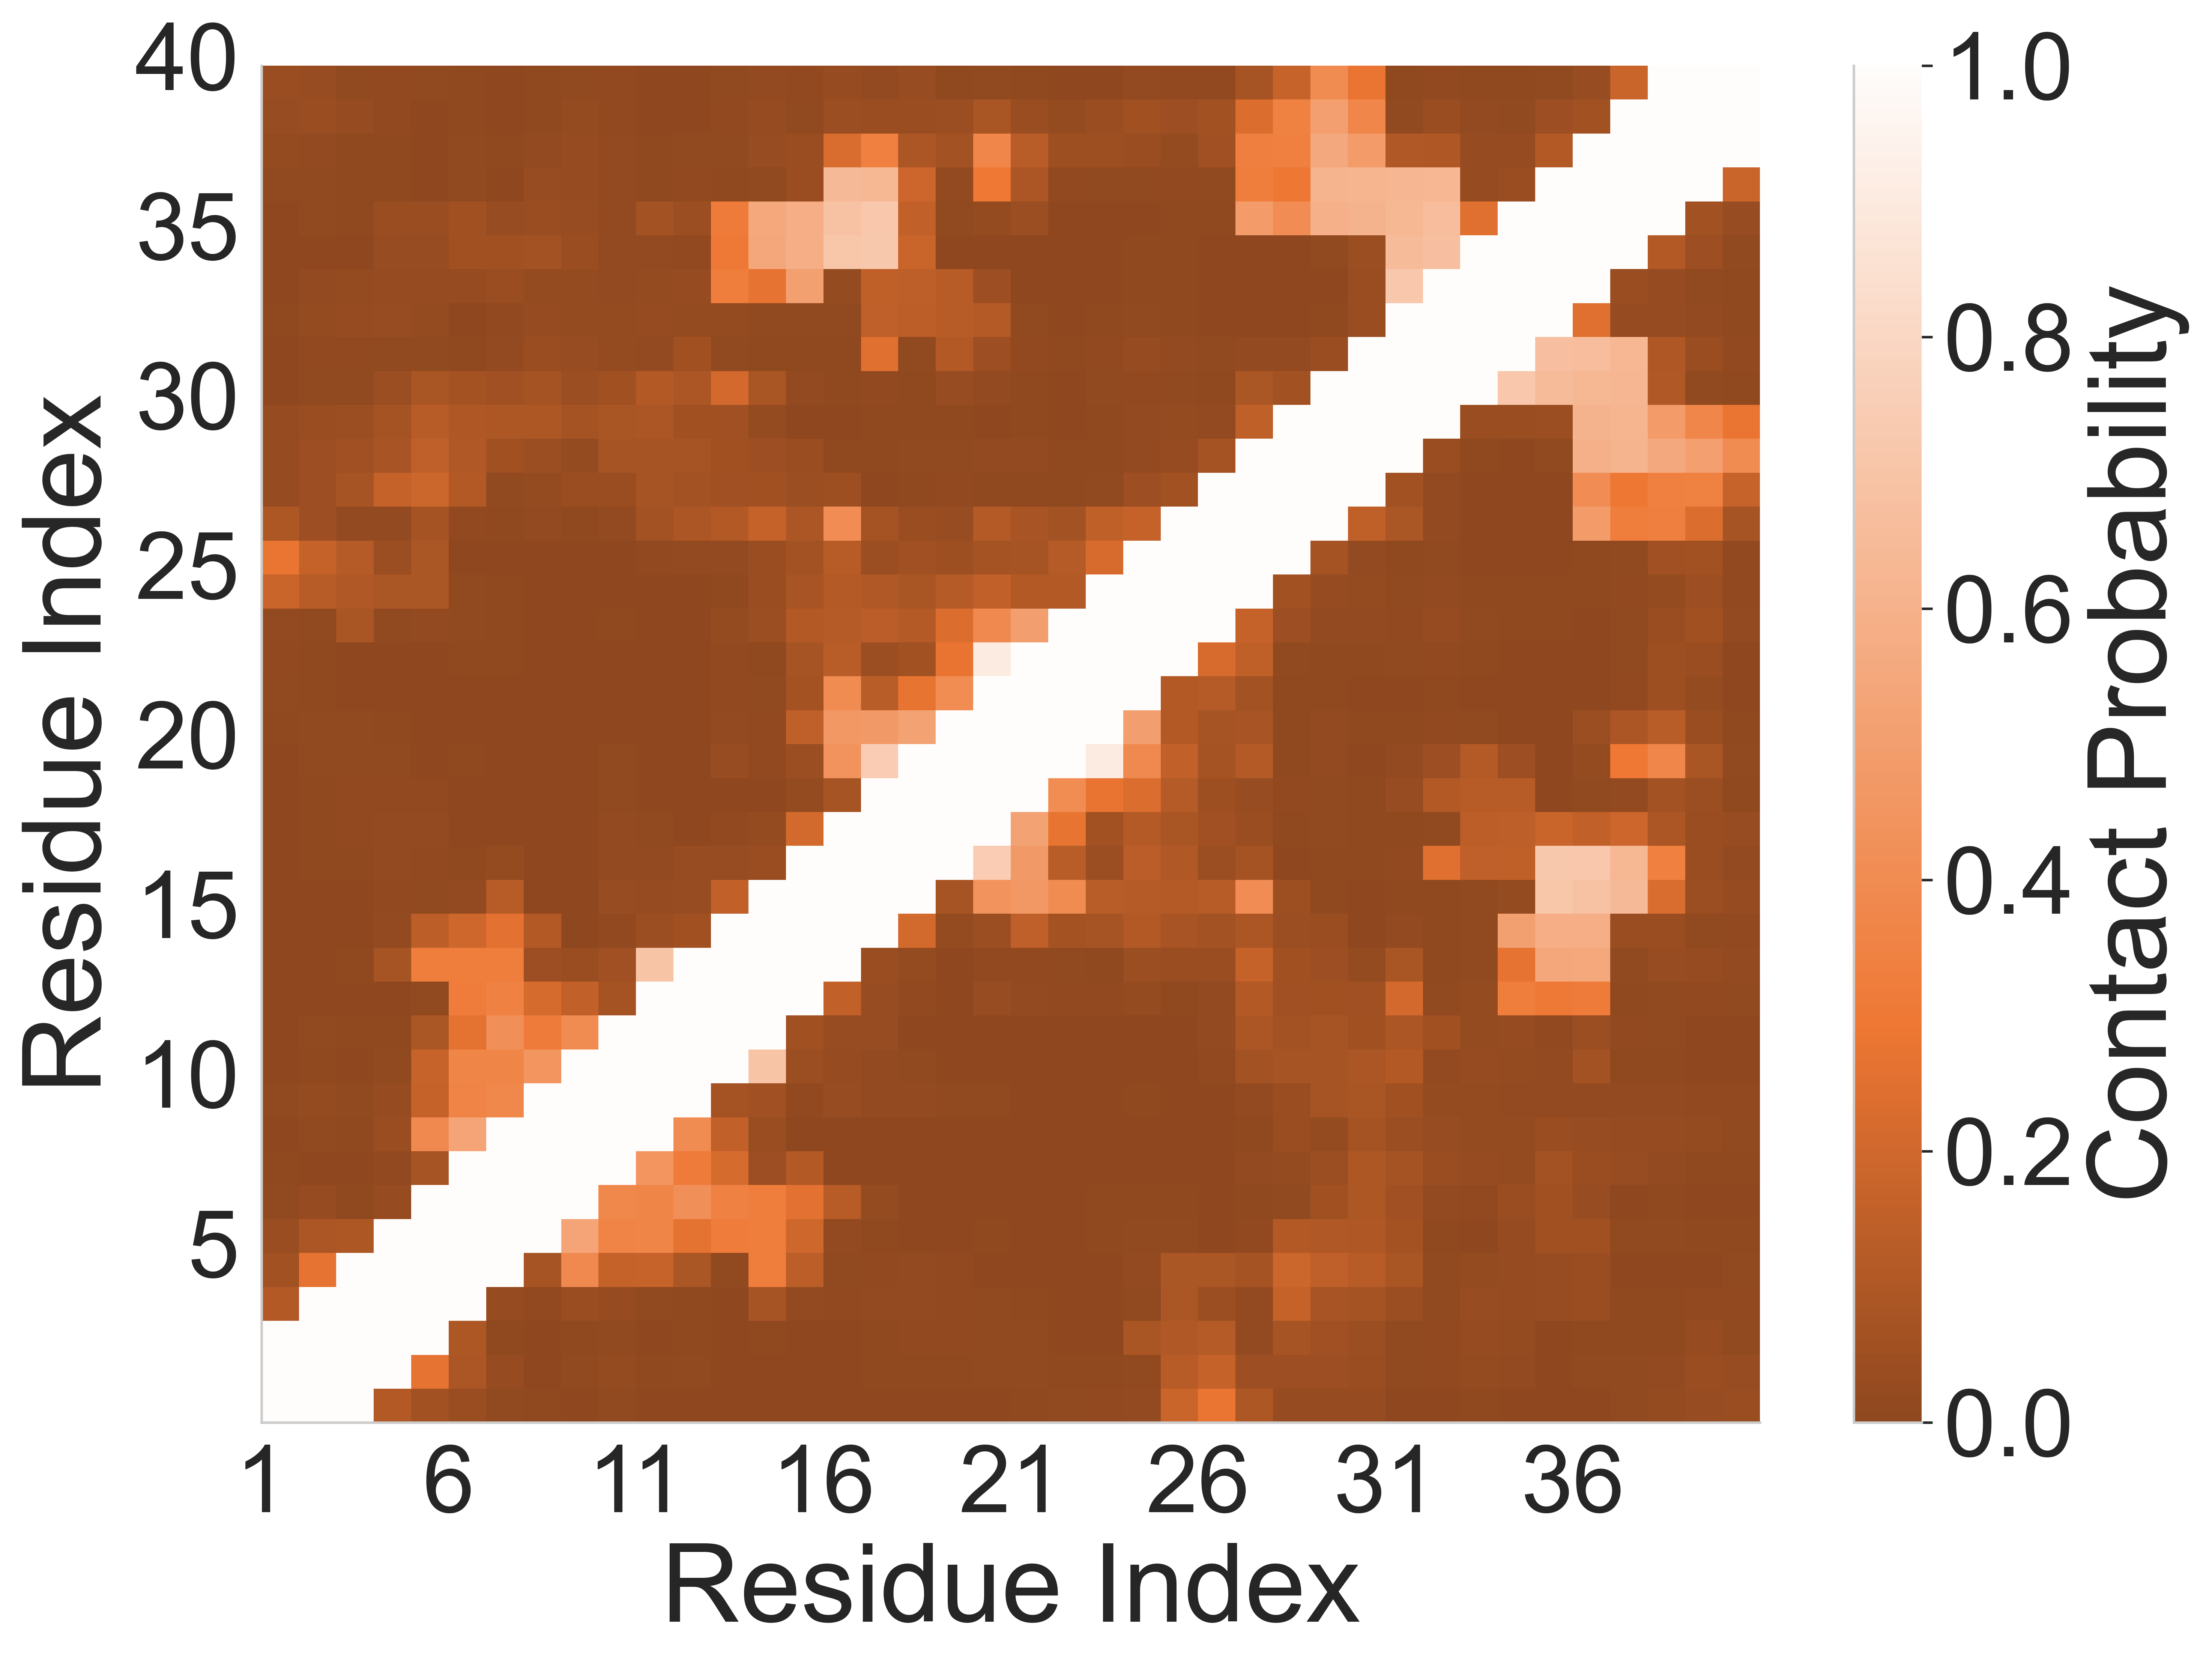

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# 设定文件路径
txt_file = "E:/a40/cont_a40p26.txt"  # 替换为您的 TXT 文件路径
png = "E:/a40/cont_a40p26.png"  # 替换为输出的 PNG 路径

# 设定颜色映射
oranges = [(0, 0, 0), '#EE7733', (1, 1, 1)] 
oranges = mpl.colors.LinearSegmentedColormap.from_list('oranges', oranges, N=1000)
oranges = mpl.colors.LinearSegmentedColormap.from_list(
          'trunc(oranges.name,.3,.99)', oranges(np.linspace(.3, .99, 1000)))

# 从 TXT 文件加载数据
df = pd.read_csv(txt_file, delim_whitespace=True, header=None)  # 根据TXT文件的格式选择合适的分隔符
df.columns = range(1, 41)  # 如果数据列数是 40，设置相应的列名
df.index = range(1, 41)  # 设置行索引

# 反转数据框
df = df.loc[::-1]

# 绘制热图
plt.figure(figsize=(10, 10), dpi=600)
sns.set_style("whitegrid")

# 创建热图，移除颜色条
ax = sns.heatmap(df, cmap=oranges,cbar_kws={'label': 'Contact Probability'})  # 这里将 cbar 设置为 False 以移除颜色条
ax.set_xlabel('Residue Index', fontsize=35)
ax.set_ylabel('Residue Index', fontsize=35)

# 设置 X 轴刻度
x_tick_positions = np.arange(0, df.shape[1], 5)  # 每5个位置
x_tick_labels = np.arange(1, df.shape[1] + 1, 5)  # 生成（1, 5, 10, ... , 40）
ax.set_xticks(x_tick_positions)  # 设置 X 轴刻度位置
ax.set_xticklabels(x_tick_labels, fontsize=30)  # 设置 X 轴刻度标签

# 设置 Y 轴刻度
y_tick_positions = np.arange(0, df.shape[0], 5)  # Y 轴每5个位置
y_tick_labels = np.arange(1, df.shape[0] + 1)[::-1][y_tick_positions]  # 反转标签（从40到1）
ax.set_yticks(y_tick_positions)  # 设置 Y 轴刻度位置
ax.set_yticklabels(y_tick_labels, fontsize=30)  # 设置 Y 轴刻度标签

# 移除外部边框
sns.despine()
cbar = ax.collections[0].colorbar  # 获取颜色条对象
cbar.set_label('Contact Probability', fontsize=35)  # 设置标签
cbar.ax.tick_params(labelsize=30)  # 设置刻度字体大小
# 保存热图
plt.tight_layout()
plt.savefig(png)
plt.show()
